In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv("coffee_shop_revenue.csv")

print(f"Kích thước tập dữ liệu ban đầu: {df.shape}")
display(df.head())

Kích thước tập dữ liệu ban đầu: (2000, 7)


,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [54]:
# Kiểm tra thông tin cấu trúc và kiểu dữ liệu của các cột
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [ ]:
# Đếm số lượng giá trị NaN trong từng cột
missing_values = df.isnull().sum()
print("Số lượng missing values trong mỗi cột:\n", missing_values)

Số lượng missing values trong mỗi cột:
 Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


In [56]:
# Kiểm tra số lượng dòng trùng lặp
duplicates_count = df.duplicated().sum()
print(f"Số dòng dữ liệu bị trùng lặp: {duplicates_count}")

# Xóa các dòng trùng lặp (nếu có) và cập nhật lại DataFrame
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Kích thước dữ liệu sau khi xóa trùng lặp: {df.shape}")

Số dòng dữ liệu bị trùng lặp: 0


In [57]:
# Chuyển tên cột thành chữ thường
df.columns = df.columns.str.lower()

print("Tên cột sau khi chuẩn hóa:")
print(df.columns.tolist())

Tên cột sau khi chuẩn hóa:
['number_of_customers_per_day', 'average_order_value', 'operating_hours_per_day', 'number_of_employees', 'marketing_spend_per_day', 'location_foot_traffic', 'daily_revenue']


In [58]:
# Tính toán Q1 (25%) và Q3 (75%) cho cột doanh thu
Q1 = df['daily_revenue'].quantile(0.25)
Q3 = df['daily_revenue'].quantile(0.75)

# Tính IQR
IQR = Q3 - Q1

# Xác định ranh giới dưới và ranh giới trên
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc bỏ các dòng chứa ngoại lệ
df_cleaned = df[~((df['daily_revenue'] < lower_bound) | (df['daily_revenue'] > upper_bound))].copy()

print(f"Số lượng dòng bị loại bỏ do là ngoại lệ: {df.shape[0] - df_cleaned.shape[0]}")
print(f"Kích thước tập dữ liệu cuối cùng (df_cleaned) sẵn sàng cho EDA: {df_cleaned.shape}")

Số lượng dòng bị loại bỏ do là ngoại lệ: 9
Kích thước tập dữ liệu cuối cùng (df_cleaned) sẵn sàng cho EDA: (1991, 7)


In [59]:
# Chọn 3 feature quan trọng nhất và biến mục tiêu
selected_features = [
    'number_of_customers_per_day', 
    'average_order_value', 
    'marketing_spend_per_day', 
    'daily_revenue'
]
df_final = df_cleaned[selected_features].copy()

print(f"Kích thước tập dữ liệu cuối cùng: {df_final.shape}")
display(df_final.head())

# Lưu thành file CSV mới
df_final.to_csv("coffee_revenue.csv", index=False)
print("Đã lưu dữ liệu vào file: coffee_revenue.csv")

Kích thước tập dữ liệu cuối cùng: (1991, 4)


,number_of_customers_per_day,average_order_value,marketing_spend_per_day,daily_revenue
0,152,6.74,106.62,1547.81
1,485,4.50,57.83,2084.68
2,398,9.09,91.76,3118.39
3,320,8.48,462.63,2912.20
4,156,7.44,412.52,1663.42


Đã lưu dữ liệu vào file: coffee_revenue.csv


In [60]:
# Thiết lập chung cho đồ thị
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Thống kê mô tả
print("--- THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU ---")
display(df_cleaned.describe().round(2))

--- THỐNG KÊ MÔ TẢ TẬP DỮ LIỆU ---


,number_of_customers_per_day,average_order_value,operating_hours_per_day,number_of_employees,marketing_spend_per_day,location_foot_traffic,daily_revenue
count,1991.00,1991.00,1991.00,1991.00,1991.00,1991.0,1991.00
mean,273.41,6.25,11.66,7.94,251.97,535.0,1904.49
std,129.05,2.17,3.44,3.74,140.79,271.9,959.45
min,50.00,2.50,6.00,2.00,10.12,50.0,-58.95
25%,163.00,4.39,9.00,5.00,129.92,302.0,1135.53
50%,274.00,6.29,12.00,8.00,250.25,540.0,1763.23
75%,384.00,8.08,15.00,11.00,374.06,767.5,2516.02
max,499.00,10.00,17.00,14.00,499.74,999.0,4591.74


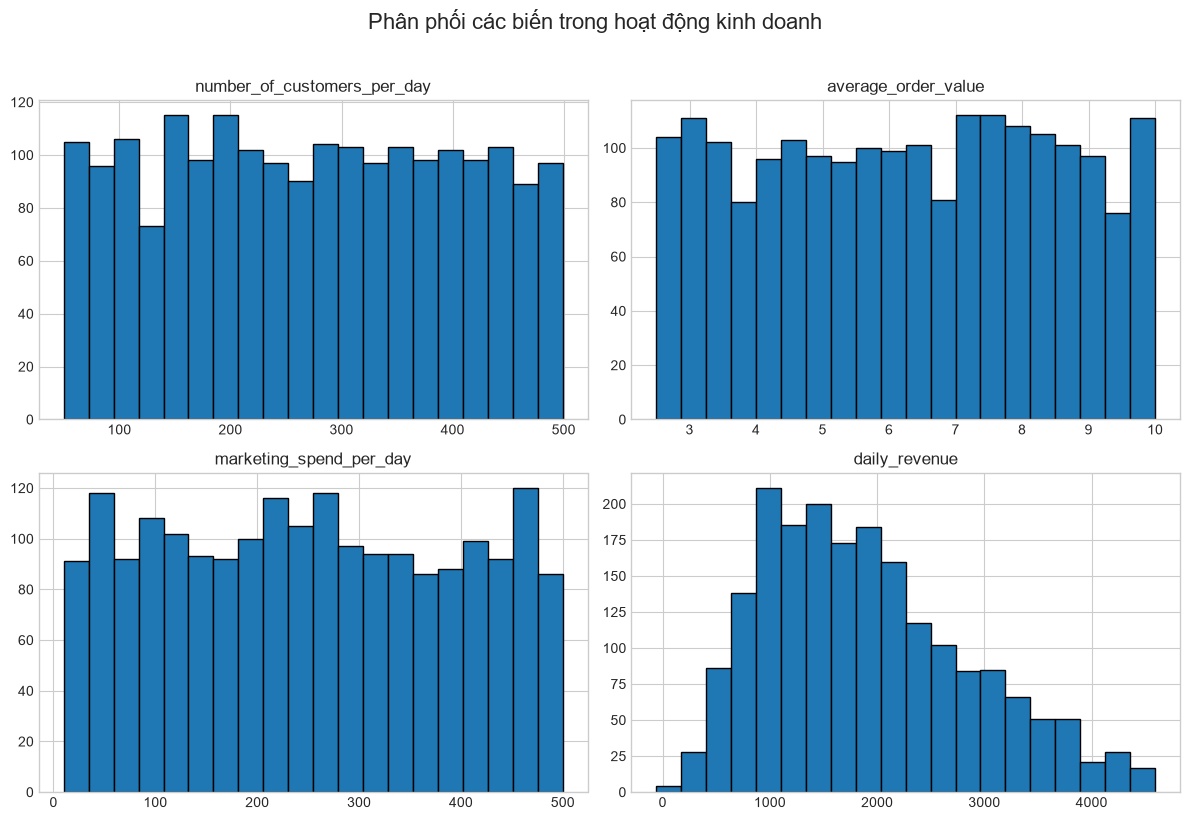

In [61]:
# 2. Histogram (Phân phối của các biến)
df_final.hist(bins=20, figsize=(12, 8), color='#1f77b4', edgecolor='black')
plt.suptitle('Phân phối các biến trong hoạt động kinh doanh', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

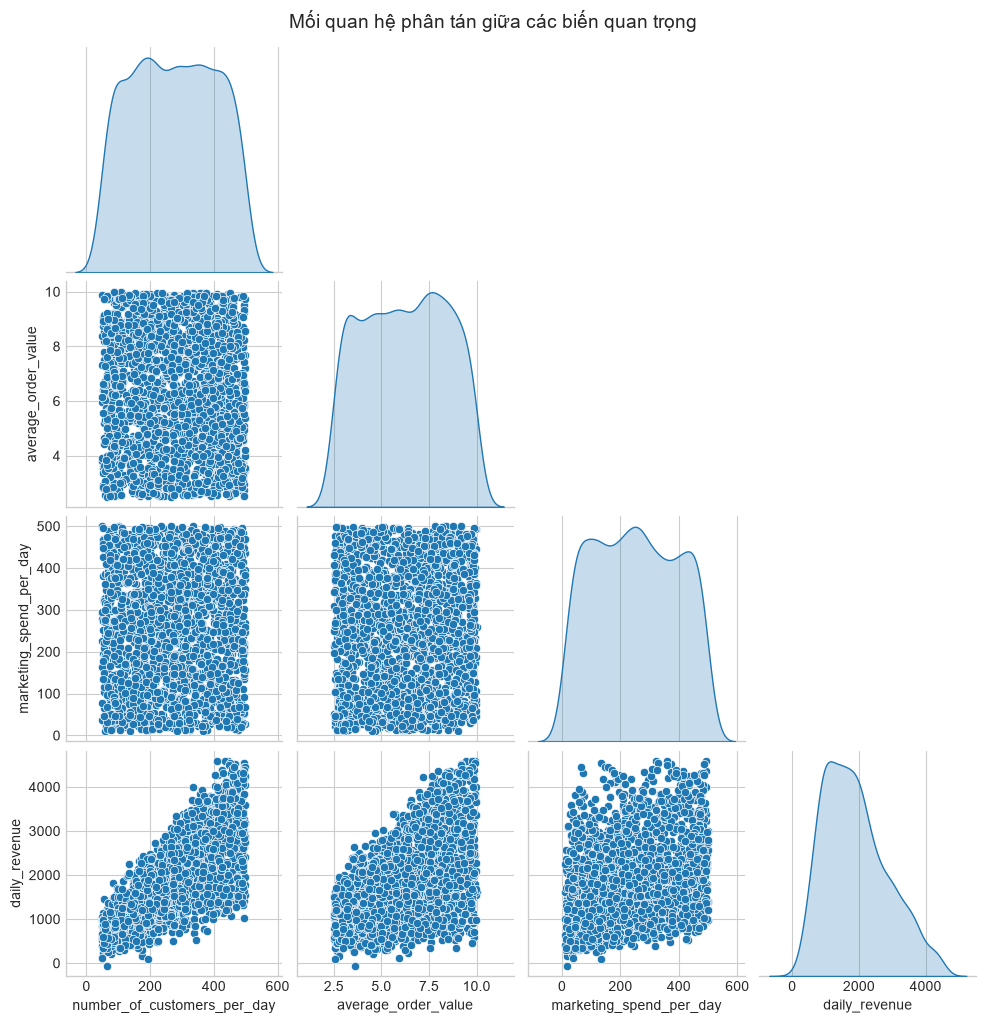

In [62]:
# 3. Pairplot (Xem xét phân tán của một số biến chính)
cols_to_plot = ['number_of_customers_per_day', 'average_order_value', 'marketing_spend_per_day', 'daily_revenue']
sns.pairplot(df_cleaned[cols_to_plot], diag_kind='kde', corner=True)
plt.suptitle('Mối quan hệ phân tán giữa các biến quan trọng', y=1.02, fontsize=14)
plt.show()

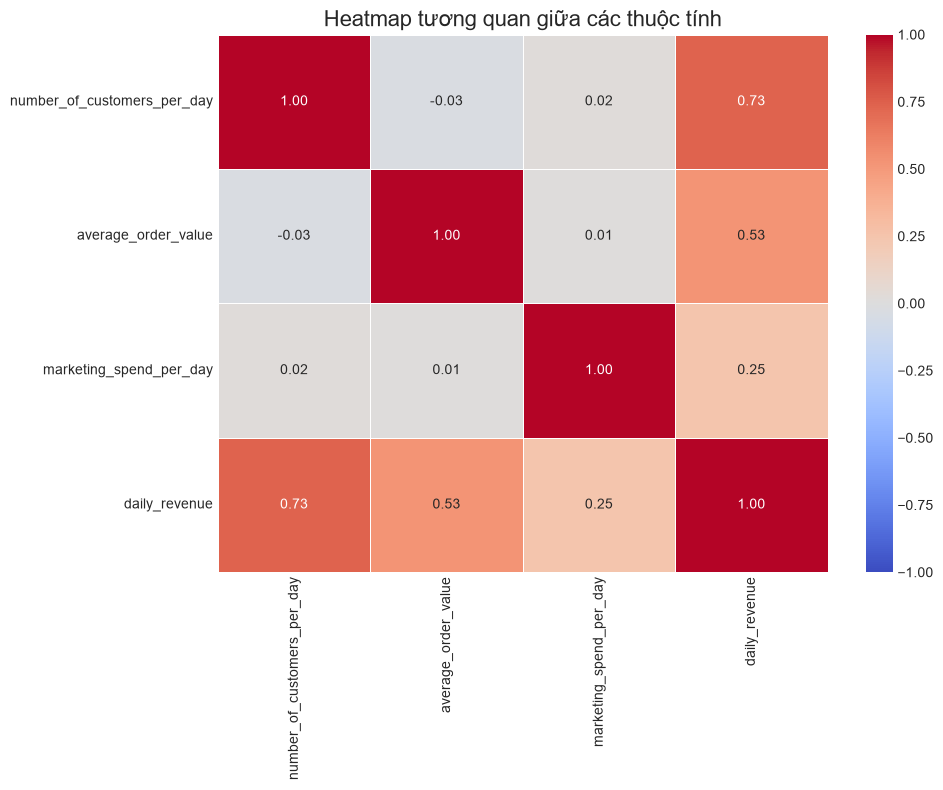

In [63]:
# 4. Heatmap (Ma trận tương quan)
plt.figure(figsize=(10, 8))
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các thuộc tính', fontsize=16)
plt.tight_layout()
plt.show()

In [64]:
print("\n--- MỨC ĐỘ TƯƠNG QUAN VỚI DOANH THU (DAILY_REVENUE) ---")
print(correlation_matrix['daily_revenue'].sort_values(ascending=False))


--- MỨC ĐỘ TƯƠNG QUAN VỚI DOANH THU (DAILY_REVENUE) ---
daily_revenue                  1.000000
number_of_customers_per_day    0.734662
average_order_value            0.527915
marketing_spend_per_day        0.247151
Name: daily_revenue, dtype: float64
